In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
check_df = pd.read_csv("../data/cleaned/Cleaned_Air_Quality_Data.xls")
print(check_df.shape)
print(check_df.columns.tolist())
check_df.head()

(29531, 19)
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Year', 'Month', 'Day']


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN,2015,1,1
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN,2015,1,2
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN,2015,1,3
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN,2015,1,4
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN,2015,1,5


In [3]:
df = pd.read_csv("../data/cleaned/Cleaned_Air_Quality_Data.xls", parse_dates=["Date"])
print(df.shape)
df.head()

(29531, 19)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN,2015,1,1
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN,2015,1,2
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN,2015,1,3
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN,2015,1,4
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN,2015,1,5


In [4]:
city_df = df[df["City"] == "Delhi"].sort_values("Date")
print(city_df.shape)
print(city_df["AQI"].isna().sum(), "missing AQI values out of", len(city_df))
city_df[["Date", "AQI"]].head(10)

(2009, 19)
10 missing AQI values out of 2009


,Date,AQI
10229,2015-01-01,472.0
10230,2015-01-02,454.0
10231,2015-01-03,143.0
10232,2015-01-04,319.0
10233,2015-01-05,325.0
10234,2015-01-06,318.0
10235,2015-01-07,353.0
10236,2015-01-08,383.0
10237,2015-01-09,375.0
10238,2015-01-10,376.0


In [5]:
series = city_df.set_index("Date")["AQI"].asfreq("D")
print(series.shape)
print("Missing before interpolation:", series.isna().sum())

series = series.interpolate()
print("Missing after interpolation:", series.isna().sum())

series.head(10)

(2009,)
Missing before interpolation: 10
Missing after interpolation: 0


Date
2015-01-01    472.0
2015-01-02    454.0
2015-01-03    143.0
2015-01-04    319.0
2015-01-05    325.0
2015-01-06    318.0
2015-01-07    353.0
2015-01-08    383.0
2015-01-09    375.0
2015-01-10    376.0
Freq: D, Name: AQI, dtype: float64

In [6]:
test_days = 90
train = series.iloc[:-test_days]
test = series.iloc[-test_days:]

print("Train:", train.shape, train.index.min(), "to", train.index.max())
print("Test:", test.shape, test.index.min(), "to", test.index.max())

Train: (1919,) 2015-01-01 00:00:00 to 2020-04-02 00:00:00
Test: (90,) 2020-04-03 00:00:00 to 2020-07-01 00:00:00


In [7]:
ma_forecast = pd.Series(train.tail(7).mean(), index=test.index)
ma_forecast.head()

Date
2020-04-03    72.0
2020-04-04    72.0
2020-04-05    72.0
2020-04-06    72.0
2020-04-07    72.0
Freq: D, dtype: float64

In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=365).fit(optimized=True, remove_bias=True)
hw_forecast = hw_model.forecast(test_days)
hw_forecast.index = test.index

hw_forecast.head()

c:\Users\DELL\OneDrive\Desktop\Enviornmental_Monitoring_and_Air_Quality_Intelligence\venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Date
2020-04-03     96.067996
2020-04-04    126.708360
2020-04-05     77.295677
2020-04-06    137.924497
2020-04-07    121.470015
Freq: D, dtype: float64

In [9]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(5, 1, 2)).fit()
arima_forecast = arima_model.forecast(test_days)
arima_forecast.index = test.index

arima_forecast.head()

Date
2020-04-03    86.423158
2020-04-04    92.494670
2020-04-05    95.392261
2020-04-06    96.725049
2020-04-07    97.503553
Freq: D, Name: predicted_mean, dtype: float64

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name:22s} | MAE: {mae:6.2f} | RMSE: {rmse:6.2f} | MAPE: {mape:5.2f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []
results.append(evaluate(test, ma_forecast, "Moving Average"))
results.append(evaluate(test, hw_forecast, "Exponential Smoothing"))
results.append(evaluate(test, arima_forecast, "ARIMA"))

results_df = pd.DataFrame(results).set_index("model")
results_df

Moving Average         | MAE:  58.17 | RMSE:  67.46 | MAPE: 41.20%
Exponential Smoothing  | MAE:  49.54 | RMSE:  64.09 | MAPE: 37.13%
ARIMA                  | MAE:  35.51 | RMSE:  47.47 | MAPE: 23.72%


,MAE,RMSE,MAPE
model,,,
Moving Average,58.166667,67.459865,41.203075
Exponential Smoothing,49.542424,64.094505,37.125646
ARIMA,35.509590,47.468764,23.718883


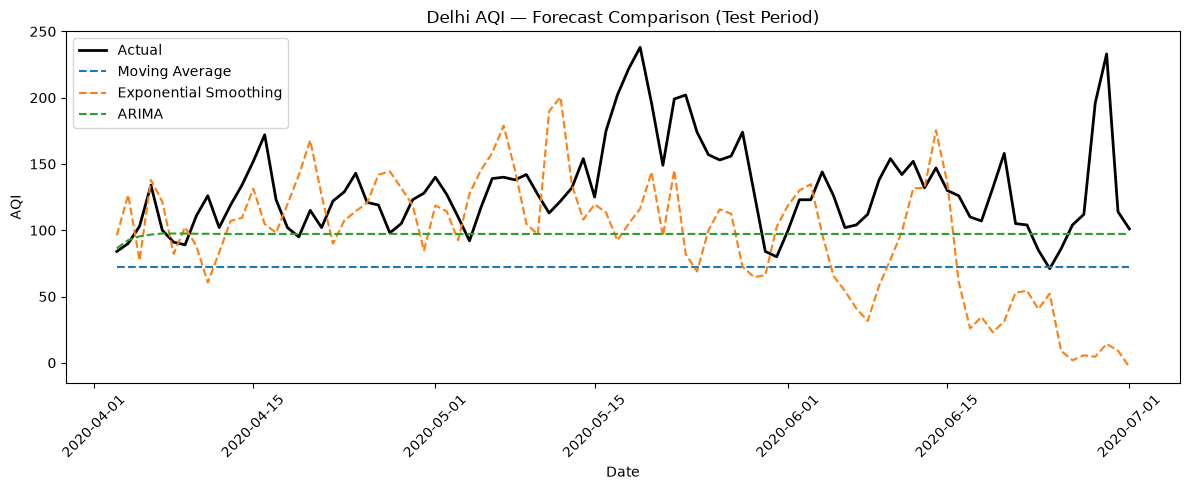

In [11]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test.values, label="Actual", color="black", linewidth=2)
plt.plot(ma_forecast.index, ma_forecast.values, label="Moving Average", linestyle="--")
plt.plot(hw_forecast.index, hw_forecast.values, label="Exponential Smoothing", linestyle="--")
plt.plot(arima_forecast.index, arima_forecast.values, label="ARIMA", linestyle="--")
plt.title("Delhi AQI — Forecast Comparison (Test Period)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary
- Compared Moving Average, Exponential Smoothing, and ARIMA for Delhi AQI forecasting.
- ARIMA(5,1,2) performed best (MAE: 35.5, RMSE: 47.5, MAPE: 23.7%).
- Test period (Apr-Jul 2020) coincided with COVID-19 lockdown, causing unusual AQI drops
  that none of the models were trained to anticipate.
- Exponential Smoothing underperformed the baseline, likely due to optimizer non-convergence
  on the strong yearly seasonality.

In [12]:
from prophet import Prophet
print("Prophet imported successfully")

c:\Users\DELL\OneDrive\Desktop\Enviornmental_Monitoring_and_Air_Quality_Intelligence\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Prophet imported successfully


In [13]:
prophet_df = train.reset_index()
prophet_df.columns = ["ds", "y"]
prophet_df.head()

,ds,y
0,2015-01-01,472.0
1,2015-01-02,454.0
2,2015-01-03,143.0
3,2015-01-04,319.0
4,2015-01-05,325.0


In [14]:
from prophet import Prophet

prophet_model = Prophet(yearly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=test_days)
forecast = prophet_model.predict(future)

prophet_forecast = forecast.set_index("ds")["yhat"].iloc[-test_days:]
prophet_forecast.index.name = "Date"

prophet_forecast.head()

02:15:30 - cmdstanpy - INFO - Chain [1] start processing
02:15:32 - cmdstanpy - INFO - Chain [1] done processing


Date
2020-04-03    203.113454
2020-04-04    199.510660
2020-04-05    195.872381
2020-04-06    193.983185
2020-04-07    198.404680
Name: yhat, dtype: float64

In [15]:
res_prophet = evaluate(test, prophet_forecast, "Prophet")
results.append(res_prophet)

results_df = pd.DataFrame(results).set_index("model")
results_df

Prophet                | MAE:  71.15 | RMSE:  81.25 | MAPE: 60.97%


,MAE,RMSE,MAPE
model,,,
Moving Average,58.166667,67.459865,41.203075
Exponential Smoothing,49.542424,64.094505,37.125646
ARIMA,35.509590,47.468764,23.718883
Prophet,71.154149,81.249939,60.968497


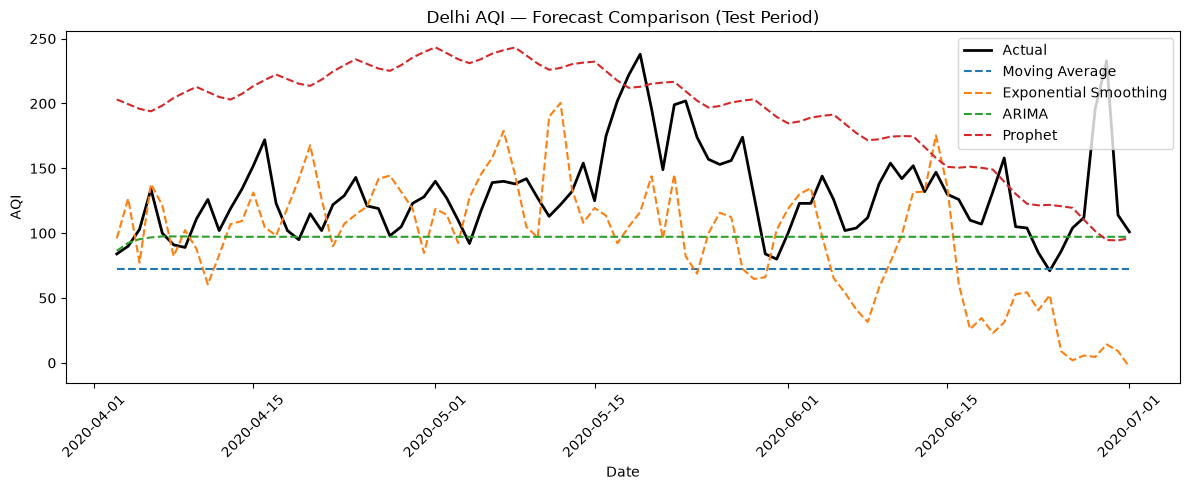

In [16]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test.values, label="Actual", color="black", linewidth=2)
plt.plot(ma_forecast.index, ma_forecast.values, label="Moving Average", linestyle="--")
plt.plot(hw_forecast.index, hw_forecast.values, label="Exponential Smoothing", linestyle="--")
plt.plot(arima_forecast.index, arima_forecast.values, label="ARIMA", linestyle="--")
plt.plot(prophet_forecast.index, prophet_forecast.values, label="Prophet", linestyle="--")
plt.title("Delhi AQI — Forecast Comparison (Test Period)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/delhi_aqi_forecast_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary
- Compared 4 forecasting approaches for Delhi AQI: Moving Average, Exponential Smoothing, ARIMA, and Prophet.
- **ARIMA(5,1,2) performed best** (MAE: 35.5, RMSE: 47.5, MAPE: 23.7%).
- Prophet underperformed despite being a modern method — its smooth trend/seasonality
  assumptions couldn't adapt to the sharp AQI swings during the COVID-19 lockdown test period.
- Test period (Apr-Jul 2020) coincided with the lockdown, causing atypical AQI drops that
  none of the models were trained to anticipate — a genuine limitation, not a code issue.